# Faizaan Ali | HW5 | Task 4 (Graduate)

# Polyp Segmentation Using U-Net on the CVC-ClinicDB Dataset

Medical image segmentation plays a critical role in computer-aided diagnosis systems.
One important application is the identification and segmentation of polyps in colonoscopy images.
Early detection of polyps can significantly improve colorectal cancer prevention.

This project focuses on the **CVC-ClinicDB dataset**, which contains colonoscopy frames
with corresponding ground-truth segmentation masks for polyps.

### Objectives
1. Explore the CVC-ClinicDB dataset
2. Implement a **U-Net segmentation model**
3. Train the model on colonoscopy images
4. Evaluate using standard segmentation metrics (Dice/IoU)
5. Compare results with existing models from research paper

### Dataset
CVC-ClinicDB:
https://polyp.grandchallenge.org/CVCClinicDB/

We use the HuggingFace dataset version:
https://huggingface.co/datasets/Angelou0516/CVC-ClinicDB

### Paper 1:

Tudela, Yael et al. “A complete benchmark for polyp detection, segmentation and classification in colonoscopy images.” Frontiers in oncology vol. 14 1417862. 24 Sep. 2024, [doi:10.3389/fonc.2024.1417862](https://pmc.ncbi.nlm.nih.gov/articles/PMC11458519/)

Recent approaches to polyp segmentation have been largely dominated by encoder–decoder architectures, particularly U-Net–based models, which effectively capture both global context and fine-grained spatial details through skip connections. Extensions such as U-Net++ improve upon this design by introducing densely connected skip pathways and multiple nested decoders, enabling better feature fusion across scales. Other variants like DUCK-Net focus on improving generalization, especially with limited medical data, by incorporating residual downsampling and multi-resolution feature extraction within the encoder.

More advanced methods incorporate attention mechanisms and transformer-based architectures to address the challenges of polyp variability in size, texture, and boundary ambiguity. Models like PraNet use reverse attention to refine boundary predictions and focus on difficult regions, while transformer-based approaches (e.g., Polyp2Seg and Pyramid Transformer models) leverage long-range dependencies and multi-scale feature aggregation to improve segmentation accuracy. Hybrid CNN-transformer models further combine local feature extraction with global context modeling, representing the current state-of-the-art in achieving robust and precise polyp segmentation.

Overall, existing research suggests that polyp detection and segmentation have reached a relatively mature stage, with many methods achieving consistently strong performance and only marginal differences between top approaches. However, challenges remain in handling difficult cases, such as small or visually ambiguous polyps, highlighting the need for more diverse and representative datasets to improve generalization. In contrast, polyp classification remains an open problem, where performance is still limited and often affected by class imbalance. Future work in this area emphasizes expanding datasets (including higher-resolution and multimodal data), improving class balance, and incorporating additional clinical information such as histology and advanced imaging modalities to better align models with real-world clinical needs.

In [1]:
!pip install datasets
!pip install torch torchvision
!pip install matplotlib
!pip install opencv-python
!pip install scikit-learn

## Load Dataset

Using device: cuda


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/981 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/123 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/123 [00:00<?, ?it/s]

...

metadata.jsonl: 0.00B [00:00, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Dataset({
    features: ['image', 'mask'],
    num_rows: 490
})


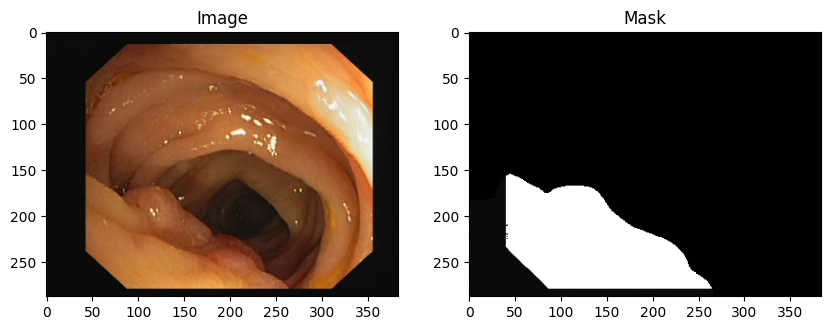

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from datasets import load_dataset

import numpy as np
import matplotlib.pyplot as plt
import cv2
from sklearn.metrics import precision_score, recall_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Load dataset
dataset = load_dataset("Angelou0516/CVC-ClinicDB")

train_data = dataset['train']
val_data = dataset['validation']
test_data = dataset['test']

print(train_data)

sample = train_data[0]

image = sample['image']
mask = sample['mask']

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Image")

plt.subplot(1,2,2)
plt.imshow(mask, cmap='gray')
plt.title("Mask")

plt.show()

## Data Loaders

In [4]:
class PolypDataset(Dataset):

    def __init__(self, dataset_split, img_size=256, augment=False, augment_factor=1):
        self.data = dataset_split
        self.img_size = img_size
        self.augment = augment
        self.augment_factor = augment_factor  # multiplies dataset size

    def __len__(self):
        return len(self.data) * self.augment_factor

    def __getitem__(self, idx):

        # wrap index if augment_factor > 1
        idx = idx % len(self.data)

        sample = self.data[idx]

        image = np.array(sample['image'])
        mask = np.array(sample['mask'])

        # Resize
        image = cv2.resize(image, (self.img_size, self.img_size),
                           interpolation=cv2.INTER_LINEAR)

        mask = cv2.resize(mask, (self.img_size, self.img_size),
                          interpolation=cv2.INTER_NEAREST)

        # DATA AUGMENTATION
        if self.augment:

            # Horizontal flip
            if np.random.rand() > 0.5:
                image = np.fliplr(image)
                mask = np.fliplr(mask)

            # Vertical flip
            if np.random.rand() > 0.5:
                image = np.flipud(image)
                mask = np.flipud(mask)

            # Rotation (90 deg increments)
            if np.random.rand() > 0.5:
                k = np.random.randint(1, 4)
                image = np.rot90(image, k)
                mask = np.rot90(mask, k)

            # Random brightness
            if np.random.rand() > 0.5:
                factor = 0.8 + 0.4 * np.random.rand()
                image = np.clip(image * factor, 0, 255)

        # NORMALIZATION
        image = image.astype(np.float32) / 255.0
        mask = (mask > 127).astype(np.float32)

        # Channel-first
        image = np.transpose(image, (2, 0, 1))

        image = torch.tensor(image, dtype=torch.float32)
        mask = torch.tensor(mask, dtype=torch.float32).unsqueeze(0)

        return image, mask


# DATASETS
#subset_size = 200
#train_subset = torch.utils.data.Subset(train_data, range(subset_size))

train_dataset = PolypDataset(train_data)
val_dataset = PolypDataset(val_data)
test_dataset = PolypDataset(test_data)

# DATALOADERS
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

# sizes
print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 62
Val batches: 8
Test batches: 8


## Model Architecture

In [5]:
class DoubleConv(nn.Module):

    def __init__(self, in_c, out_c):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(),

            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU()
        )

    def forward(self, x):
        return self.net(x)


class UNet(nn.Module):

    def __init__(self):
        super().__init__()

        self.down1 = DoubleConv(3,64)
        self.down2 = DoubleConv(64,128)
        self.down3 = DoubleConv(128,256)

        self.pool = nn.MaxPool2d(2)

        self.upconv1 = nn.ConvTranspose2d(256,128,2,stride=2)
        self.up1 = DoubleConv(128+128,128)

        self.upconv2 = nn.ConvTranspose2d(128,64,2,stride=2)
        self.up2 = DoubleConv(64+64,64)

        self.out = nn.Conv2d(64,1,1)

    def forward(self,x):

        d1 = self.down1(x)
        p1 = self.pool(d1)

        d2 = self.down2(p1)
        p2 = self.pool(d2)

        d3 = self.down3(p2)

        u1 = self.upconv1(d3)
        u1 = torch.cat([u1,d2],dim=1)
        u1 = self.up1(u1)

        u2 = self.upconv2(u1)
        u2 = torch.cat([u2,d1],dim=1)
        u2 = self.up2(u2)

        return torch.sigmoid(self.out(u2))

class DiceLoss(nn.Module):

    def __init__(self):
        super().__init__()

    def forward(self, pred, target):

        smooth = 1e-6

        pred = pred.view(-1)
        target = target.view(-1)

        intersection = (pred * target).sum()

        dice = (2 * intersection + smooth) / (pred.sum() + target.sum() + smooth)

        return 1 - dice

def dice_score(pred, target):

    smooth = 1e-6

    pred = pred.view(-1)
    target = target.view(-1)

    intersection = (pred * target).sum()

    return (2*intersection + smooth) / (pred.sum() + target.sum() + smooth)

def iou_score(pred, target):

    pred = pred.view(-1)
    target = target.view(-1)

    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection

    return intersection / (union + 1e-6)

Our U-Net architecture is a compact, three-level encoder-decoder network designed for polyp segmentation. The encoder path consists of three DoubleConv blocks, each performing two consecutive 3×3 convolutions followed by Batch Normalization and ReLU activations. After each block, a 2×2 max pooling operation downsamples the feature maps, progressively capturing higher-level semantic information while reducing spatial resolution. The feature channels increase from 64 to 128 to 256 as we go deeper, allowing the network to encode increasingly complex patterns and structures.

The decoder path mirrors the encoder but uses transposed convolutions to upsample the feature maps. At each level, we concatenate the upsampled feature map with the corresponding encoder output (skip connections) to retain spatial details lost during pooling. The concatenated features are then processed by another DoubleConv block to refine the segmentation. Finally, a 1×1 convolution maps the output to a single-channel mask, and a sigmoid activation produces values between 0 and 1, for binary segmentation.

## Training

Epoch 1/30
Train Loss: 0.7291
Val Loss:   0.7032
Val Dice:   0.3949
------------------------------
Epoch 2/30
Train Loss: 0.6877
Val Loss:   0.6995
Val Dice:   0.3804
------------------------------
Epoch 3/30
Train Loss: 0.6687
Val Loss:   0.6742
Val Dice:   0.4480
------------------------------
Epoch 4/30
Train Loss: 0.6556
Val Loss:   0.6792
Val Dice:   0.4046
------------------------------
Epoch 5/30
Train Loss: 0.6373
Val Loss:   0.6552
Val Dice:   0.4832
------------------------------
Epoch 6/30
Train Loss: 0.6111
Val Loss:   0.6253
Val Dice:   0.4727
------------------------------
Epoch 7/30
Train Loss: 0.5893
Val Loss:   0.6199
Val Dice:   0.4691
------------------------------
Epoch 8/30
Train Loss: 0.5801
Val Loss:   0.5925
Val Dice:   0.5106
------------------------------
Epoch 9/30
Train Loss: 0.5560
Val Loss:   0.5743
Val Dice:   0.5368
------------------------------
Epoch 10/30
Train Loss: 0.5347
Val Loss:   0.5412
Val Dice:   0.5738
------------------------------
Epoch 11/

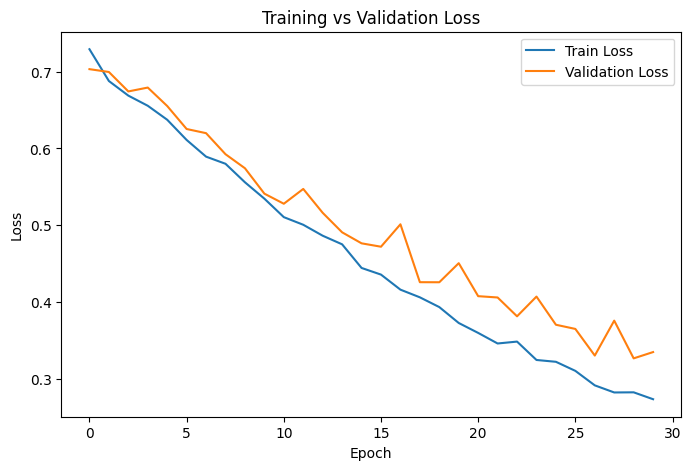

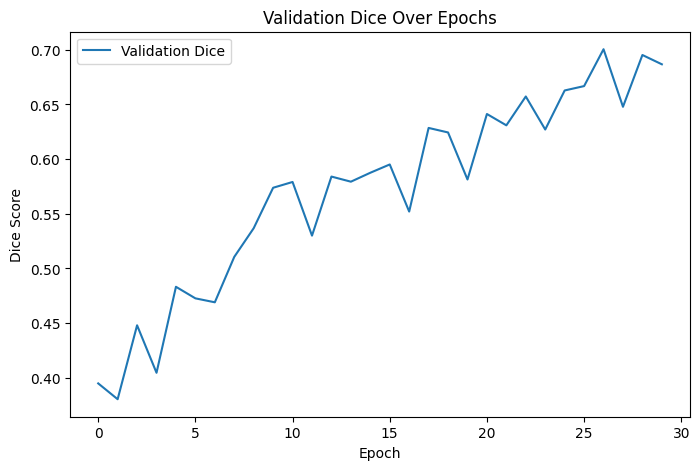

In [6]:
import matplotlib.pyplot as plt

model = UNet().to(device)

criterion = DiceLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

epochs = 30

train_losses = []
val_losses = []
val_dice_scores = []

best_dice = 0

for epoch in range(epochs):

    # -------- TRAINING -------
    model.train()
    total_train_loss = 0

    for images, masks in train_loader:

        images = images.to(device)
        masks = masks.to(device)

        preds = model(images)
        loss = criterion(preds, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # ------ VALIDATION --------
    model.eval()
    total_val_loss = 0
    dice_scores = []

    with torch.no_grad():
        for images, masks in val_loader:

            images = images.to(device)
            masks = masks.to(device)

            preds = model(images)

            loss = criterion(preds, masks)
            total_val_loss += loss.item()

            preds_bin = (preds > 0.5).float()
            dice = dice_score(preds_bin, masks)
            dice_scores.append(dice.item())

    avg_val_loss = total_val_loss / len(val_loader)
    avg_val_dice = np.mean(dice_scores)

    if avg_val_dice > best_dice:
        best_dice = avg_val_dice
        torch.save(model.state_dict(), "best_model.pth")

    val_losses.append(avg_val_loss)
    val_dice_scores.append(avg_val_dice)

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Train Loss: {avg_train_loss:.4f}")
    print(f"Val Loss:   {avg_val_loss:.4f}")
    print(f"Val Dice:   {avg_val_dice:.4f}")
    print("-"*30)

plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

plt.figure(figsize=(8,5))

plt.plot(val_dice_scores, label="Validation Dice")

plt.xlabel("Epoch")
plt.ylabel("Dice Score")
plt.title("Validation Dice Over Epochs")
plt.legend()

plt.show()

## Eval

### Segmentation Metrics: Dice and IoU

### Dice Score
The **Dice coefficient** measures how much the predicted mask overlaps with the ground truth mask.

$
\text{Dice} = \frac{2 |P \cap G|}{|P| + |G|}
$

- \(P\): predicted mask  
- \(G\): ground truth mask  
- \(P $\cap$ G\): overlapping pixels  

**Interpretation:**
- Ranges from **0 to 1**
- **1 = perfect overlap**
- More sensitive to overlap quality than simple accuracy

### Intersection over Union (IoU / Jaccard Index)
The **IoU** measures the ratio of overlap to the total combined area.

$
\text{IoU} = \frac{|P \cap G|}{|P \cup G|}
$

- \(P $\cup$ G\): total area covered by prediction and ground truth  

**Interpretation:**
- Ranges from **0 to 1**
- **1 = perfect match**
- Penalizes both false positives and false negatives more strictly than Dice

### Key Difference
- **Dice** is more forgiving (emphasizes overlap)
- **IoU** is stricter (penalizes extra/missed regions more)

Mean Dice: 0.7688510492444038
Mean IoU: 0.6256019994616508


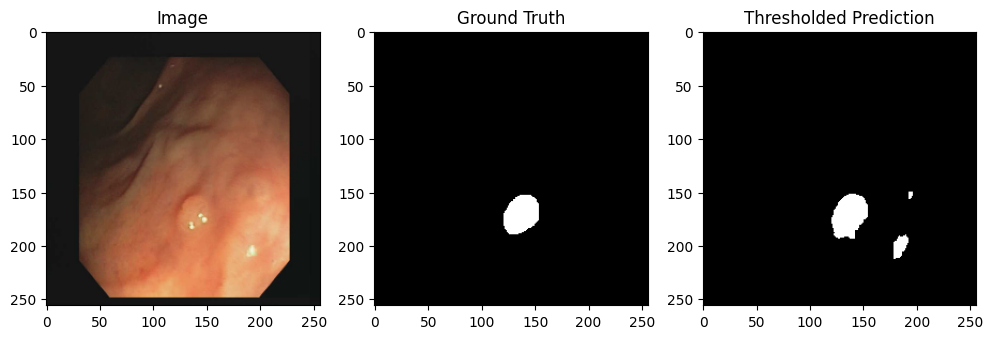

In [7]:
import random


model.eval()

dice_scores = []
iou_scores = []

with torch.no_grad():

    for images, masks in test_loader:

        images = images.to(device)
        masks = masks.to(device)

        preds = model(images)

        preds = (preds > 0.5).float()

        dice = dice_score(preds, masks)
        iou = iou_score(preds, masks)

        dice_scores.append(dice.item())
        iou_scores.append(iou.item())

print("Mean Dice:", np.mean(dice_scores))
print("Mean IoU:", np.mean(iou_scores))


# Get a random batch
batch = random.choice(list(test_loader))
images, masks = batch

# Pick a random index within the batch
idx = random.randint(0, images.shape[0] - 1)

image = images[idx]
mask = masks[idx]
with torch.no_grad():
    preds = model(images.to(device)).cpu()

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(images[0].permute(1,2,0))
plt.title("Image")

plt.subplot(1,3,2)
plt.imshow(masks[0][0], cmap='gray')
plt.title("Ground Truth")

plt.subplot(1,3,3)

plt.imshow(preds[0][0], cmap='gray')
plt.title("Raw Prediction")

plt.imshow(preds[0][0] > 0.5, cmap='gray')
plt.title("Thresholded Prediction")

plt.show()

In [8]:
model.eval()

dice_scores = []
ious = []
pixel_accuracies = []

with torch.no_grad():

    for images, masks in test_loader:

        images = images.to(device)
        masks = masks.to(device)

        preds = model(images)

        # STANDARD THRESHOLD
        preds = (preds > 0.5).float()

        for i in range(images.size(0)):

            pred = preds[i][0]
            gt = masks[i][0]

            # flatten
            pred_flat = pred.view(-1)
            gt_flat = gt.view(-1)

            # Dice
            intersection = (pred_flat * gt_flat).sum()
            dice = (2. * intersection + 1e-6) / (pred_flat.sum() + gt_flat.sum() + 1e-6)
            dice_scores.append(dice.item())

            # IoU
            union = pred_flat.sum() + gt_flat.sum() - intersection
            iou = (intersection + 1e-6) / (union + 1e-6)
            ious.append(iou.item())

            # Pixel Accuracy
            correct = (pred_flat == gt_flat).sum()
            total = gt_flat.numel()
            acc = correct / total
            pixel_accuracies.append(acc.item())


# ---- FINAL METRICS ----
mean_dice = np.mean(dice_scores)
mean_iou = np.mean(ious)
mean_pixel_acc = np.mean(pixel_accuracies)

print("=== TEST SET SEGMENTATION RESULTS ===")
print(f"Mean Dice Score: {mean_dice:.4f}")
print(f"Mean IoU (mIoU): {mean_iou:.4f}")
print(f"Pixel Accuracy: {mean_pixel_acc:.4f}")

=== TEST SET SEGMENTATION RESULTS ===
Mean Dice Score: 0.7230
Mean IoU (mIoU): 0.5927
Pixel Accuracy: 0.9555


## Paper Comparison

*A Comprehensive Study on Colorectal Polyp Segmentation With ResUNet++, Conditional Random Field and Test-Time Augmentation*

D. Jha et al., "A Comprehensive Study on Colorectal Polyp Segmentation With ResUNet++, Conditional Random Field and Test-Time Augmentation," in IEEE Journal of Biomedical and Health Informatics, vol. 25, no. 6, pp. 2029-2040, June 2021, doi: [10.1109/JBHI.2021.3049304.](https://ieeexplore.ieee.org/document/9314114)



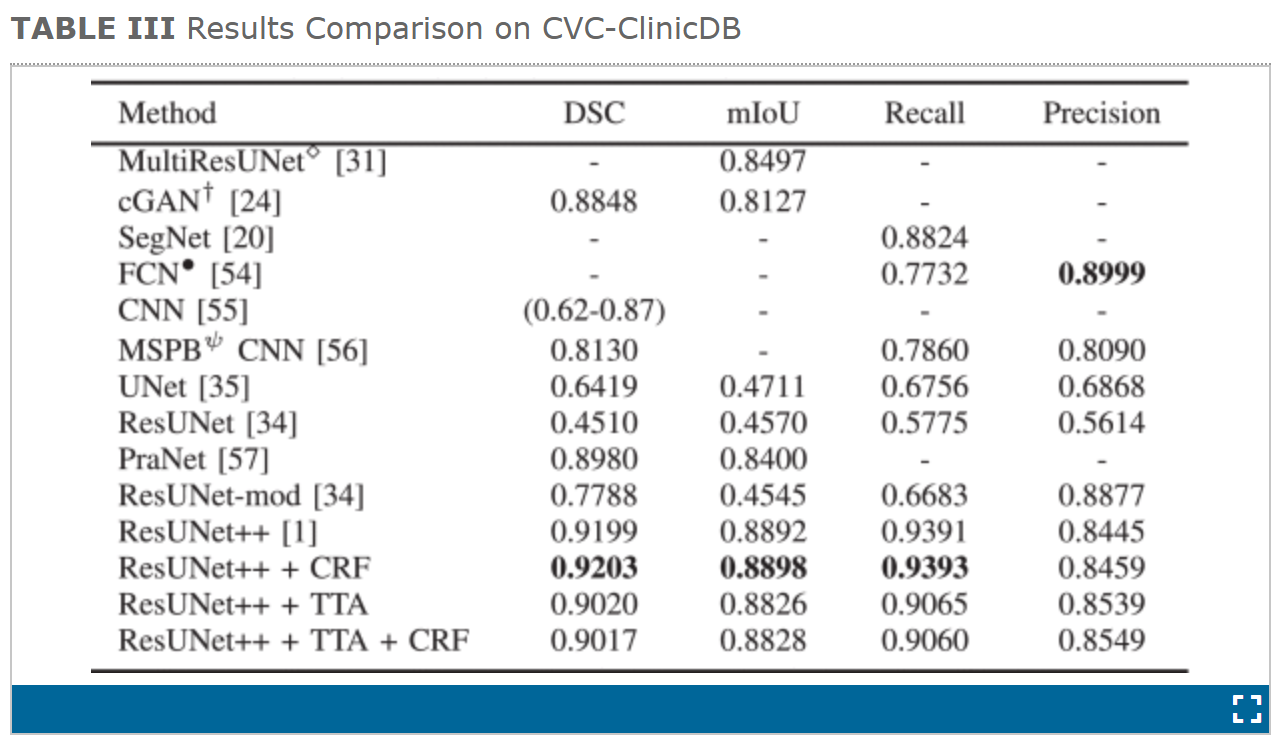

The results (**Dice ≈ 0.72, IoU ≈ 0.59**) are **solid but clearly below survey/paper-level performance**. This is seen especially where modern polyp segmentation methods (e.g., ResUNet++, PraNet, TransUNet) typically report **Dice ≈ 0.85–0.92** and **IoU ≈ 0.75–0.88**. This gap is expected given the architecture: we are using a **minimal 3-level U-Net**, whereas survey models incorporate deeper encoders, attention mechanisms, or pretrained backbones. So the model is performing well for a baseline, but it lacks the representational power needed to capture the complex polyp boundaries and texture variations.

The main limitations come from both **architecture and training setup**. Architecturally, the U-Net is relatively shallow (only three downsampling stages) and does not include **multi-scale context aggregation**, **attention gates**, or **residual connections**, all of which are critical for segmenting irregular, low-contrast polyps. This makes it harder for the model to detect small or ambiguous regions, lowering Dice and IoU. Additionally, while the overall pixel accuracy is high (~0.96), this is misleading due to class imbalance. Most pixels are background, so the model can achieve high accuracy without truly precise segmentation. Overall, the results show a **strong baseline**, but the gap to survey-level performance highlights the need for bigger architectures, better loss functions, and more complex feature extraction.
